<a href="https://colab.research.google.com/github/mhizbulloh/Tugas/blob/main/Tugas%20Citra%20DIgital%20ke%202(hasil%20negatif%2C%20power%20low%2C%20dan%20logaritmik).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving download.jpg to download (5).jpg


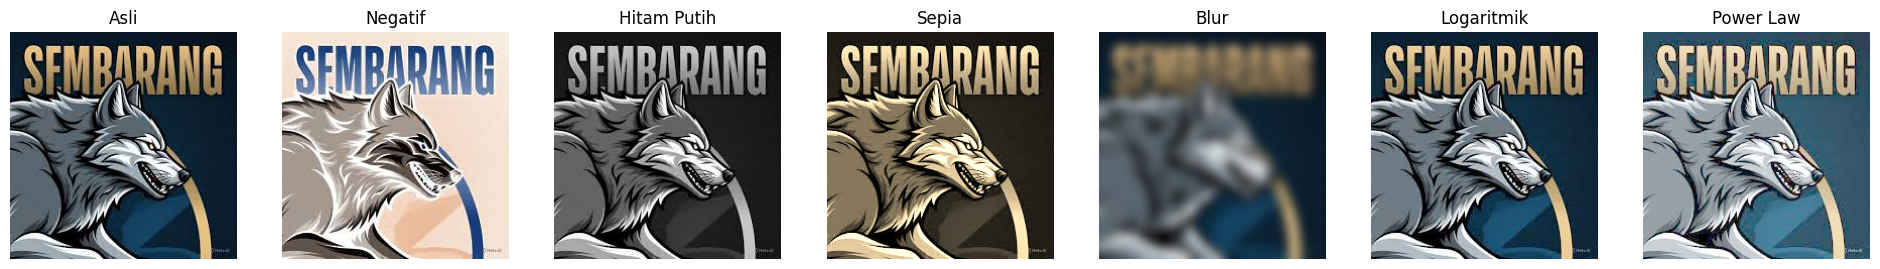

In [8]:
from google.colab import files
from PIL import Image, ImageOps, ImageFilter
import matplotlib.pyplot as plt
import io
import numpy as np

def apply_sepia(img):
    width, height = img.size
    pixels = img.load()
    for py in range(height):
        for px in range(width):
            r, g, b = img.getpixel((px, py))
            tr = int(0.393 * r + 0.769 * g + 0.189 * b)
            tg = int(0.349 * r + 0.686 * g + 0.168 * b)
            tb = int(0.272 * r + 0.534 * g + 0.131 * b)
            pixels[px, py] = (min(tr, 255), min(tg, 255), min(tb, 255))
    return img

def log_transform(img, c=1):
    # Apply log transformation: s = c * log(1 + r)
    # r is normalized to [0, 1], then scaled back to [0, 255]
    img_array = np.array(img).astype(np.float32)
    normalized_img = img_array / 255.0
    transformed_img = c * np.log(1 + normalized_img)
    # Scale back to 0-255 and convert to uint8
    transformed_img = (transformed_img / np.max(transformed_img)) * 255.0
    return Image.fromarray(transformed_img.astype(np.uint8))

def power_law_transform(img, gamma=0.5, c=1):
    # Apply power law transformation: s = c * r^gamma
    # r is normalized to [0, 1], then scaled back to [0, 255]
    img_array = np.array(img).astype(np.float32)
    normalized_img = img_array / 255.0
    transformed_img = c * np.power(normalized_img, gamma)
    # Scale back to 0-255 and convert to uint8
    transformed_img = (transformed_img / np.max(transformed_img)) * 255.0
    return Image.fromarray(transformed_img.astype(np.uint8))

uploaded = files.upload()

for filename in uploaded.keys():
    try:
        original = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

        # 1. Negatif
        negatif = ImageOps.invert(original)

        # 2. Grayscale
        grayscale = ImageOps.grayscale(original)

        # 3. Sepia
        sepia = apply_sepia(original.copy())

        # 4. Blur
        blur = original.filter(ImageFilter.GaussianBlur(radius=5))

        # 5. Logaritmik
        log_transformed = log_transform(original.copy())

        # 6. Power Law (Gamma correction)
        power_law_transformed = power_law_transform(original.copy(), gamma=0.5)

        # Menampilkan semua varian
        effects = [original, negatif, grayscale, sepia, blur, log_transformed, power_law_transformed]
        titles = ["Asli", "Negatif", "Hitam Putih", "Sepia", "Blur", "Logaritmik", "Power Law"]

        plt.figure(figsize=(24, 8)) # Adjust figure size for more plots
        for i in range(len(effects)):
            plt.subplot(1, len(effects), i+1)
            plt.imshow(effects[i], cmap='gray' if titles[i]=="Hitam Putih" else None)
            plt.title(titles[i])
            plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Gagal memproses {filename}: {e}")